In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification

In [126]:
X,y=make_classification(n_samples=1000,n_features=2,n_classes=2,n_clusters_per_class=2,n_redundant=0)

In [127]:


X

array([[-1.3293243 , -1.63855778],
       [ 2.01315537,  0.19811487],
       [ 1.43776668,  0.91176872],
       ...,
       [-0.75549734,  2.18119545],
       [-1.03103501,  1.75643411],
       [ 1.23282669, -0.67233158]])

In [128]:
y

array([0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1,

In [129]:
pd.DataFrame(X)[0]

,0
0,-1.329324
1,2.013155
2,1.437767
3,-1.192786
4,-0.867685
...,...
995,-1.495463
996,2.168164
997,-0.755497
998,-1.031035


<Axes: xlabel='0', ylabel='1'>

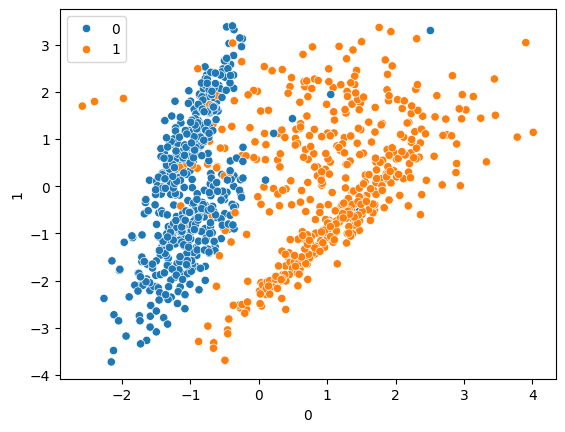

In [130]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [131]:
from sklearn.model_selection import train_test_split

In [132]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,
                                               random_state=10)

In [133]:
from sklearn.svm import SVC

In [134]:
svc=SVC()

In [135]:
svc.fit(X_train,y_train)

SVC()

In [136]:
y_pred=svc.predict(X_test)

In [137]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [138]:
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.964
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       109
           1       1.00      0.94      0.97       141

    accuracy                           0.96       250
   macro avg       0.96      0.97      0.96       250
weighted avg       0.97      0.96      0.96       250

[[109   0]
 [  9 132]]


##Hyperparameter Tunining

In [139]:
from sklearn.model_selection import GridSearchCV

In [140]:
para={
    'C':[0.1,1,10,50,100,500],
    'gamma':[1,0.1,0.01,0.001]
      }

In [141]:
grid=GridSearchCV(SVC(),param_grid=para,verbose=3,cv=5,refit=True)

In [142]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV 1/5] END ....................C=0.1, gamma=1;, score=0.953 total time=   0.0s
[CV 2/5] END ....................C=0.1, gamma=1;, score=0.947 total time=   0.0s
[CV 3/5] END ....................C=0.1, gamma=1;, score=0.927 total time=   0.0s
[CV 4/5] END ....................C=0.1, gamma=1;, score=0.940 total time=   0.0s
[CV 5/5] END ....................C=0.1, gamma=1;, score=0.947 total time=   0.0s
[CV 1/5] END ..................C=0.1, gamma=0.1;, score=0.927 total time=   0.0s
[CV 2/5] END ..................C=0.1, gamma=0.1;, score=0.933 total time=   0.0s
[CV 3/5] END ..................C=0.1, gamma=0.1;, score=0.913 total time=   0.0s
[CV 4/5] END ..................C=0.1, gamma=0.1;, score=0.920 total time=   0.0s
[CV 5/5] END ..................C=0.1, gamma=0.1;, score=0.927 total time=   0.0s
[CV 1/5] END .................C=0.1, gamma=0.01;, score=0.900 total time=   0.1s
[CV 2/5] END .................C=0.1, gamma=0.01

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 50, 100, 500],
                         'gamma': [1, 0.1, 0.01, 0.001]},
             verbose=3)

In [143]:
grid.best_params_

{'C': 1, 'gamma': 1}

In [144]:
y_pred=grid.predict(X_test)

In [145]:
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.968
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       109
           1       1.00      0.94      0.97       141

    accuracy                           0.97       250
   macro avg       0.97      0.97      0.97       250
weighted avg       0.97      0.97      0.97       250

[[109   0]
 [  8 133]]


##92% to 96% accuracy